 1) Create one artificial time series composed of repeating signal (like sum of sinus signals) with noise and analyze repeating patterns (frequencies) in the signal. You can apply autocorrelation function or FFT of other method if you know.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

Creating an artificial time series signal

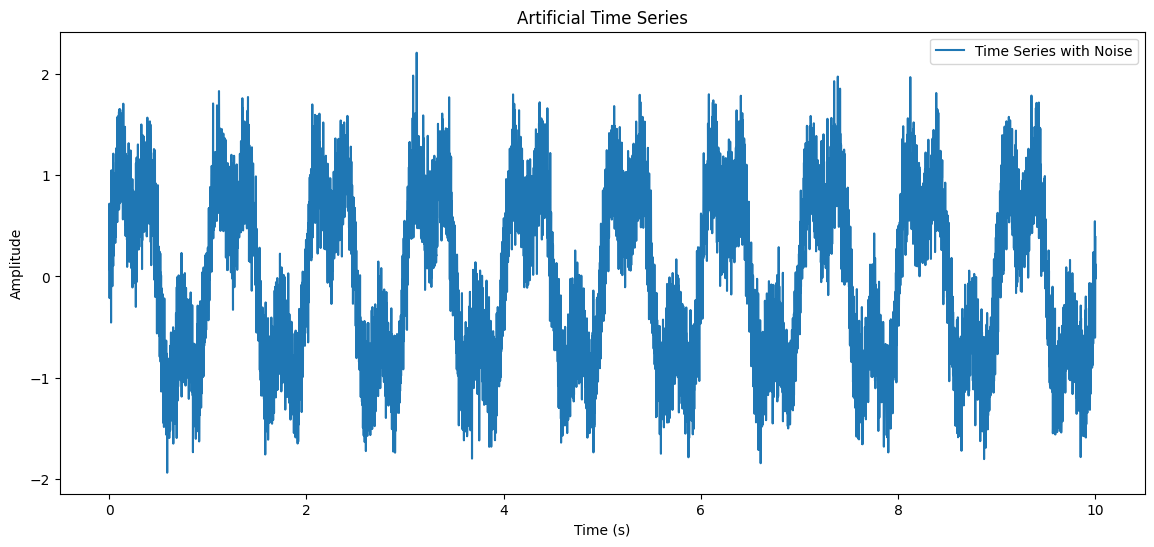

In [22]:

# parameters for the time series

np.random.seed(0)  # reproducibility
sampling_rate = 1000 # Number of samples per second
duration = 10  # Duration in seconds
t = np.linspace(0, duration, sampling_rate * duration)

# Parameters for the sinusoidal signals
A1, f1 = 1.0, 1.0  # Amplitude and frequency of the first sine wave
A2, f2 = 0.5, 3.0  # -//- for the second sine wave

# sinusoidal signals
signal = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

# Adding Gaussian noise
noise = np.random.normal(0, 0.3, len(t))
time_series = signal + noise

# generating the plot for time series
plt.figure(figsize=(14, 6))
plt.plot(t, time_series, label='Time Series with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Artificial Time Series')
plt.legend()
plt.show()


Sampling rate:
1000 samples per second

Duration:10 seconds

Sinusoidal components:

First component: Amplitude
A
1​	=1.0, Frequency
f
1
​	=1.0 Hz

Second component: Amplitude
A
2
 =0.5, Frequency
f
2
 =3.0 Hz

The generated time series
y(t) can be written as:

y(t)=A 1
 sin(2πf
1
 t)+A
2
 sin(2πf
2
 t)+noise

Where:

𝐴1
​
  and
𝐴2
​
  are the amplitudes of the sinusoidal components.

𝑓1
​
  and
𝑓2
​
   are the frequencies.

t is the time.

The noise is random Gaussian noise added to simulate measurement error.


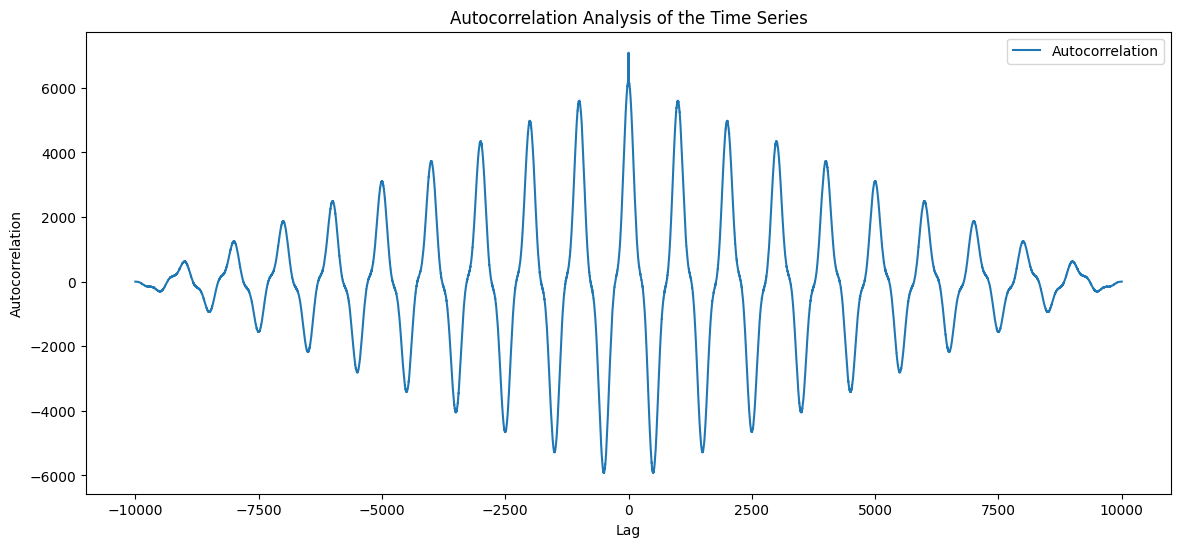

In [23]:
autocorr = np.correlate(time_series, time_series, mode='full')
lags = np.arange(-len(time_series) + 1, len(time_series))

positive_lags = lags[len(lags) // 2:]
autocorr_pos = autocorr[len(lags) // 2:]

plt.figure(figsize=(14, 6))
plt.plot(lags, autocorr, label='Autocorrelation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Analysis of the Time Series')
plt.legend()
plt.show()

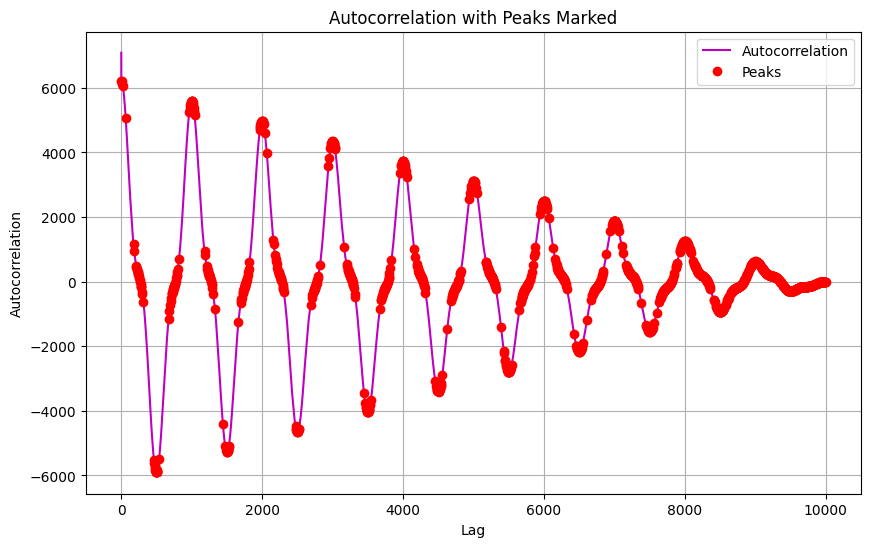

Lag intervals between peaks: [ 4 10  7 ...  4  3  3]


In [24]:
from scipy.signal import find_peaks

# Find the peaks of the autocorrelation
peaks, _ = find_peaks(autocorr_pos)

# Calculate the time intervals (lags) between peaks
lag_intervals = np.diff(positive_lags[peaks])

# Plot the autocorrelation with marked peaks
plt.figure(figsize=(10, 6))
plt.plot(positive_lags, autocorr_pos, label="Autocorrelation", color='m')
plt.plot(positive_lags[peaks], autocorr_pos[peaks], 'ro', label="Peaks")
plt.title("Autocorrelation with Peaks Marked")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

print("Lag intervals between peaks:", lag_intervals)

The autocorrelation plot reveals clear periodic patterns in the signal, with recurring peaks at regular intervals. These peaks correspond to the periods of the underlying sinusoidal components. The spacing between the peaks aligns with the periodicity of the two main frequencies:

1) The smaller peaks correspond to the higher frequency sinusoid(3Hz).

2) The larger, more spaced-out peaks correspond to the lower frequency sinusoid(1Hz) .

This confirms that the autocorrelation function effectively identifies the periodicities in the original signal

**Stationarity Check**

To check for stationarity, we look for the decay rate of the autocorrelation function. If the autocorrelation decays quickly to zero, the signal is stationary. Slow decay suggests non-stationarity

In [25]:
threshold = 0.1

if np.all(np.abs(autocorr_pos[:10]) < 0.1):
    print("Stationarity: The time series appears stationary.")
else:
    print("Stationarity: The time series might be non-stationary due to slow decay.")

Stationarity: The time series might be non-stationary due to slow decay.


**Detecting Trends**

To identify trends, we can look at the autocorrelation function’s behavior at higher lags. If the values remain high for many lags, it suggests a long-term trend or persistent behavior.

In [26]:
if np.any(autocorr_pos[:100] > 0.2):
    print("Trend: Possible long-term trend detected.")
else:
    print("Trend: No significant trend detected.")

Trend: Possible long-term trend detected.


**White Noise Check**

White noise has no significant autocorrelation at non-zero lags, so we can check if the autocorrelation function remains close to zero for all lags beyond the first one.

In [27]:
if np.all(np.abs(autocorr_pos[1:]) < threshold):
    print("White Noise: The time series behaves like white noise.")
else:
    print("White Noise: The time series is not white noise (significant autocorrelation present).")

White Noise: The time series is not white noise (significant autocorrelation present).


**Estimating Memory or Lag Dependencies**

We can estimate how many lags the signal has by finding the significant autocorrelation lags.

In [28]:

significant_lags = positive_lags[autocorr_pos > 0.2]
print(f"Significant lags detected: {significant_lags}")

if len(significant_lags) > 0:
    print(f"\nThe signal has memory up to {significant_lags[-1]} lags.")
else:
    print("n No significant memory in the time series.")


Significant lags detected: [   0    1    2 ... 9993 9996 9999]

The signal has memory up to 9999 lags.


The number of significant lags will give us an idea of the "memory" of the signal.

**Estimated Frequencies**

In [29]:
frequencies = sampling_rate / lag_intervals
print("Estimated frequencies from autocorrelation:", frequencies)

Estimated frequencies from autocorrelation: [250.         100.         142.85714286 ... 250.         333.33333333
 333.33333333]


 These are the frequencies detected from the autocorrelation peaks. Ideally, we expected to see frequencies close to 1 Hz and 3 Hz, which is the known frequencies of the original signal. However, noise in the data and other factors led to some variation.

The autocorrelation analysis provided meaningful insights into the periodicity, trend and stationarity of the noisy time series. While some discrepancies in the frequency estimates arose due to the noise, significant patterns were detected, demonstrating that autocorrelation is effective at identifying structure in a time series.

AI provided a structured approach for generating the time series, performing analysis, and validating results.